In [76]:
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score ,  precision_recall_curve
import numpy as np




In [77]:
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
X_test  = pd.read_csv('X_test.csv')
y_test  = pd.read_csv('y_test.csv').squeeze()

In [78]:

X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

In [79]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest':       RandomForestClassifier(n_jobs=-1),
    'XGBoost':            XGBClassifier(eval_metric='aucpr', n_jobs=-1),
    'LightGBM':           LGBMClassifier(is_unbalance=True,n_jobs=-1),
}


In [80]:

results = {}
for name, model in models.items():
    
    model.fit(X_train_res, y_train_res)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR':  average_precision_score(y_test, y_proba),
        'Report':  classification_report(y_test, y_pred)
    }
    print(f"\n── {name} ──")
    print(f"AUC-ROC: {results[name]['AUC-ROC']:.4f} | AUC-PR: {results[name]['AUC-PR']:.4f}")
    print(results[name]['Report'])

C:\Users\M0_obe\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



── LogisticRegression ──
AUC-ROC: 0.9674 | AUC-PR: 0.2795
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.10      0.87      0.19      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.92      0.59    555719
weighted avg       1.00      0.97      0.98    555719


── RandomForest ──
AUC-ROC: 0.9932 | AUC-PR: 0.9248
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.90      0.85      0.87      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.92      0.94    555719
weighted avg       1.00      1.00      1.00    555719


── XGBoost ──
AUC-ROC: 0.9991 | AUC-PR: 0.9476
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.80      0.93      0.86      2145

    accuracy          

In [81]:

model = RandomForestClassifier(n_jobs=-1,class_weight='balanced')

model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

result = {
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR':  average_precision_score(y_test, y_proba),
        'Report':  classification_report(y_test, y_pred)
    }



In [82]:
print(f"\n── RF-unbalanced ──")
print(f"AUC-ROC: {result['AUC-ROC']:.4f} | AUC-PR: {result['AUC-PR']:.4f}")
print(result['Report'])


── RF-unbalanced ──
AUC-ROC: 0.9934 | AUC-PR: 0.9503
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.98      0.79      0.87      2145

    accuracy                           1.00    555719
   macro avg       0.99      0.89      0.94    555719
weighted avg       1.00      1.00      1.00    555719



In [83]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]  # ~258

models = {
    "xgb" : XGBClassifier(scale_pos_weight=ratio, n_jobs=-1),
    "lgbm":LGBMClassifier(scale_pos_weight=ratio, n_jobs=-1)
}

In [84]:
results = {}
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR':  average_precision_score(y_test, y_proba),
        'Report':  classification_report(y_test, y_pred)
    }
    print(f"\n── {name} ──")
    print(f"AUC-ROC: {results[name]['AUC-ROC']:.4f} | AUC-PR: {results[name]['AUC-PR']:.4f}")
    print(results[name]['Report'])


── xgb ──
AUC-ROC: 0.9992 | AUC-PR: 0.9529
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.65      0.96      0.78      2145

    accuracy                           1.00    555719
   macro avg       0.83      0.98      0.89    555719
weighted avg       1.00      1.00      1.00    555719


── lgbm ──
AUC-ROC: 0.9687 | AUC-PR: 0.2755
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.20      0.95      0.33      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.97      0.66    555719
weighted avg       1.00      0.99      0.99    555719



In [85]:


def evaluate_at_best_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = f1_scores.argmax()
    best_threshold = thresholds[best_idx]
    y_pred = (y_proba >= best_threshold).astype(int)
    print(f"Best threshold: {best_threshold:.4f}")
    print(classification_report(y_test, y_pred))
    print(f"AUC-PR: {average_precision_score(y_test, y_proba):.4f}")

In [86]:
rf_model   = RandomForestClassifier(n_jobs=-1, class_weight='balanced').fit(X_train, y_train)
xgb_model  = XGBClassifier(eval_metric='aucpr', n_jobs=-1).fit(X_train_res, y_train_res)
lgbm_model = LGBMClassifier(is_unbalance=True, n_jobs=-1).fit(X_train_res, y_train_res)

In [87]:
models = {
    'RF':       rf_model,
    'XGBoost':  xgb_model,
    'LightGBM': lgbm_model
}

for name, model in models.items():
    print(f"\n── {name} ──")
    evaluate_at_best_threshold(model, X_test, y_test)


── RF ──
Best threshold: 0.3100
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.92      0.88      0.90      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.94      0.95    555719
weighted avg       1.00      1.00      1.00    555719

AUC-PR: 0.9492

── XGBoost ──
Best threshold: 0.7966
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.90      0.88      0.89      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.94      0.95    555719
weighted avg       1.00      1.00      1.00    555719

AUC-PR: 0.9476

── LightGBM ──
Best threshold: 0.8766
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.91      0.84      0.87      2145

    accuracy                           1.0

In [88]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ── Random Forest ──────────────────────────────────────────────────────────────
rf_params = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    estimator  = RandomForestClassifier(n_jobs=-1, class_weight='balanced'),
    param_distributions = rf_params,
    n_iter     = 20,          # try 20 random combinations
    scoring    = 'average_precision',  # optimize for AUC-PR
    cv         = 3,           # 3-fold cross validation
    n_jobs     = -1,
    random_state = 42,
    verbose    = 2
)
rf_search.fit(X_train, y_train)  # no SMOTE needed for RF
print("Best RF params:", rf_search.best_params_)
print("Best RF AUC-PR:", rf_search.best_score_)




Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best RF AUC-PR: 0.961535541823503


In [89]:
# ── XGBoost ────────────────────────────────────────────────────────────────────
xgb_pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='aucpr', n_jobs=-1))
])

xgb_params = {
    'model__n_estimators':  [100, 300, 500],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__scale_pos_weight': [1, ratio],  # let it choose between SMOTE-balanced vs weighted
}

xgb_search = RandomizedSearchCV(
    estimator  = xgb_pipe,
    param_distributions = xgb_params,
    n_iter     = 20,
    scoring    = 'average_precision',
    cv         = 3,
    n_jobs     = -1,
    random_state = 42,
    verbose    = 2
)
xgb_search.fit(X_train, y_train)  # original X_train, SMOTE is inside the pipeline
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB AUC-PR:", xgb_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB params: {'model__subsample': 0.6, 'model__scale_pos_weight': 1, 'model__n_estimators': 500, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best XGB AUC-PR: 0.9667904648262974


In [90]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
gbm_pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(objective='binary',scale_pos_weight=172, n_jobs=-1,verbose=-1))
])
lgbm_params = {
    'n_estimators':    [100, 300, 500],
    'max_depth':       [3, 5, 7, -1],
    'learning_rate':   [0.01, 0.05, 0.1],
    'subsample':       [0.6, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.8, 1.0],
    'num_leaves':      [31, 63, 127],
    'min_child_samples':[20, 50, 100],
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(objective='binary',scale_pos_weight=172, n_jobs=-1,verbose=-1),
    param_distributions=lgbm_params,
    n_iter=20,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

lgbm_search.fit(X_train, y_train)

print("Best LGBM params:", lgbm_search.best_params_)
print("Best LGBM CV AUC-PR:", lgbm_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best LGBM params: {'subsample': 0.6, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best LGBM CV AUC-PR: 0.9594520482017916


In [91]:
final_model = XGBClassifier(subsample=0.6, scale_pos_weight=ratio, n_estimators=500, max_depth=7, learning_rate=0.1, colsample_bytree= 1.0,eval_metric='aucpr', n_jobs=-1)

final_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [92]:
def optimize_threshold(
    model, X_test, y_test, target_recall=0.90, cost_fn=10, cost_fp=1
):
    from sklearn.metrics import precision_recall_curve, classification_report
    import numpy as np

    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    # ── 1. Target recall ──────────────────────────────────────────────────────
    valid = np.where(recall[:-1] >= target_recall)[0]
    if len(valid):
        best_idx = valid[np.argmax(precision[valid])]
        t_recall = thresholds[best_idx]
    else:
        t_recall = None
        print(f"[!] Model cannot reach recall={target_recall} at any threshold")

    # ── 2. Cost-based ─────────────────────────────────────────────────────────
    n = len(y_test)
    n_pos = y_test.sum()
    fp = (1 - precision[:-1]) * (recall[:-1] * n_pos) / precision[:-1]
    fn = (1 - recall[:-1]) * n_pos
    costs = cost_fp * fp + cost_fn * fn
    t_cost = thresholds[np.argmin(costs)]

    # ── Report ────────────────────────────────────────────────────────────────
    for label, threshold in [("Target Recall", t_recall), ("Cost-Based", t_cost)]:
        if threshold is None:
            continue
        y_pred = (y_proba >= threshold).astype(int)
        print(f"\n── {label} (threshold={threshold:.4f}) ──")
        print(classification_report(y_test, y_pred))

    return {"target_recall_threshold": t_recall, "cost_based_threshold": t_cost}

In [93]:
results = optimize_threshold(
    final_model, X_test, y_test, target_recall=0.90, cost_fn=10, cost_fp=1
)


── Target Recall (threshold=0.8113) ──
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.91      0.90      0.91      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.95      0.95    555719
weighted avg       1.00      1.00      1.00    555719


── Cost-Based (threshold=0.2054) ──
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.77      0.95      0.85      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.97      0.92    555719
weighted avg       1.00      1.00      1.00    555719



In [102]:
y_proba = final_model.predict_proba(X_test)[:, 1]
best_threshold = 0.2054

y_pred_custom = (y_proba >= best_threshold).astype(int)

In [103]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# Assuming y_test contains your true labels
# and y_pred_custom contains your thresholded predictions

# 1. Print the text-based classification report (Precision, Recall, F1-score)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom))

# 2. Print raw numerical confusion matrix
print("--- Raw Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_custom)
print(cm)



--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.80      0.94      0.86      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.97      0.93    555719
weighted avg       1.00      1.00      1.00    555719

--- Raw Confusion Matrix ---
[[553068    506]
 [   127   2018]]


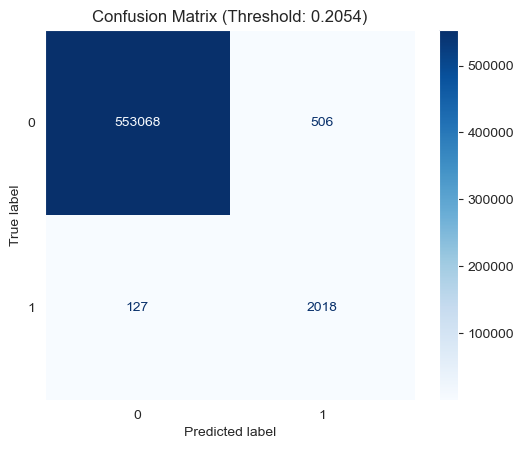

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)

# Plot it
disp.plot(cmap=plt.cm.Blues)
disp.ax_.grid(False)
plt.title(f"Confusion Matrix (Threshold: {best_threshold})")
plt.show()

In [107]:
final_model = XGBClassifier(subsample=0.6, scale_pos_weight=1, n_estimators=500, max_depth=7, learning_rate=0.1, colsample_bytree= 1.0,eval_metric='aucpr', n_jobs=-1)

final_model.fit(X_train_res,y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [108]:
results = optimize_threshold(
    final_model, X_test, y_test, target_recall=0.90, cost_fn=10, cost_fp=1
)


── Target Recall (threshold=0.6907) ──
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.93      0.90      0.92      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.95      0.96    555719
weighted avg       1.00      1.00      1.00    555719


── Cost-Based (threshold=0.1149) ──
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.74      0.95      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.98      0.92    555719
weighted avg       1.00      1.00      1.00    555719



In [145]:
y_proba = final_model.predict_proba(X_test)[:, 1]
best_threshold = 0.1149

y_pred_custom = (y_proba >= best_threshold).astype(int)

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.74      0.95      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.98      0.92    555719
weighted avg       1.00      1.00      1.00    555719

--- Raw Confusion Matrix ---
[[0.99867046 0.00132954]
 [0.04522145 0.95477855]]


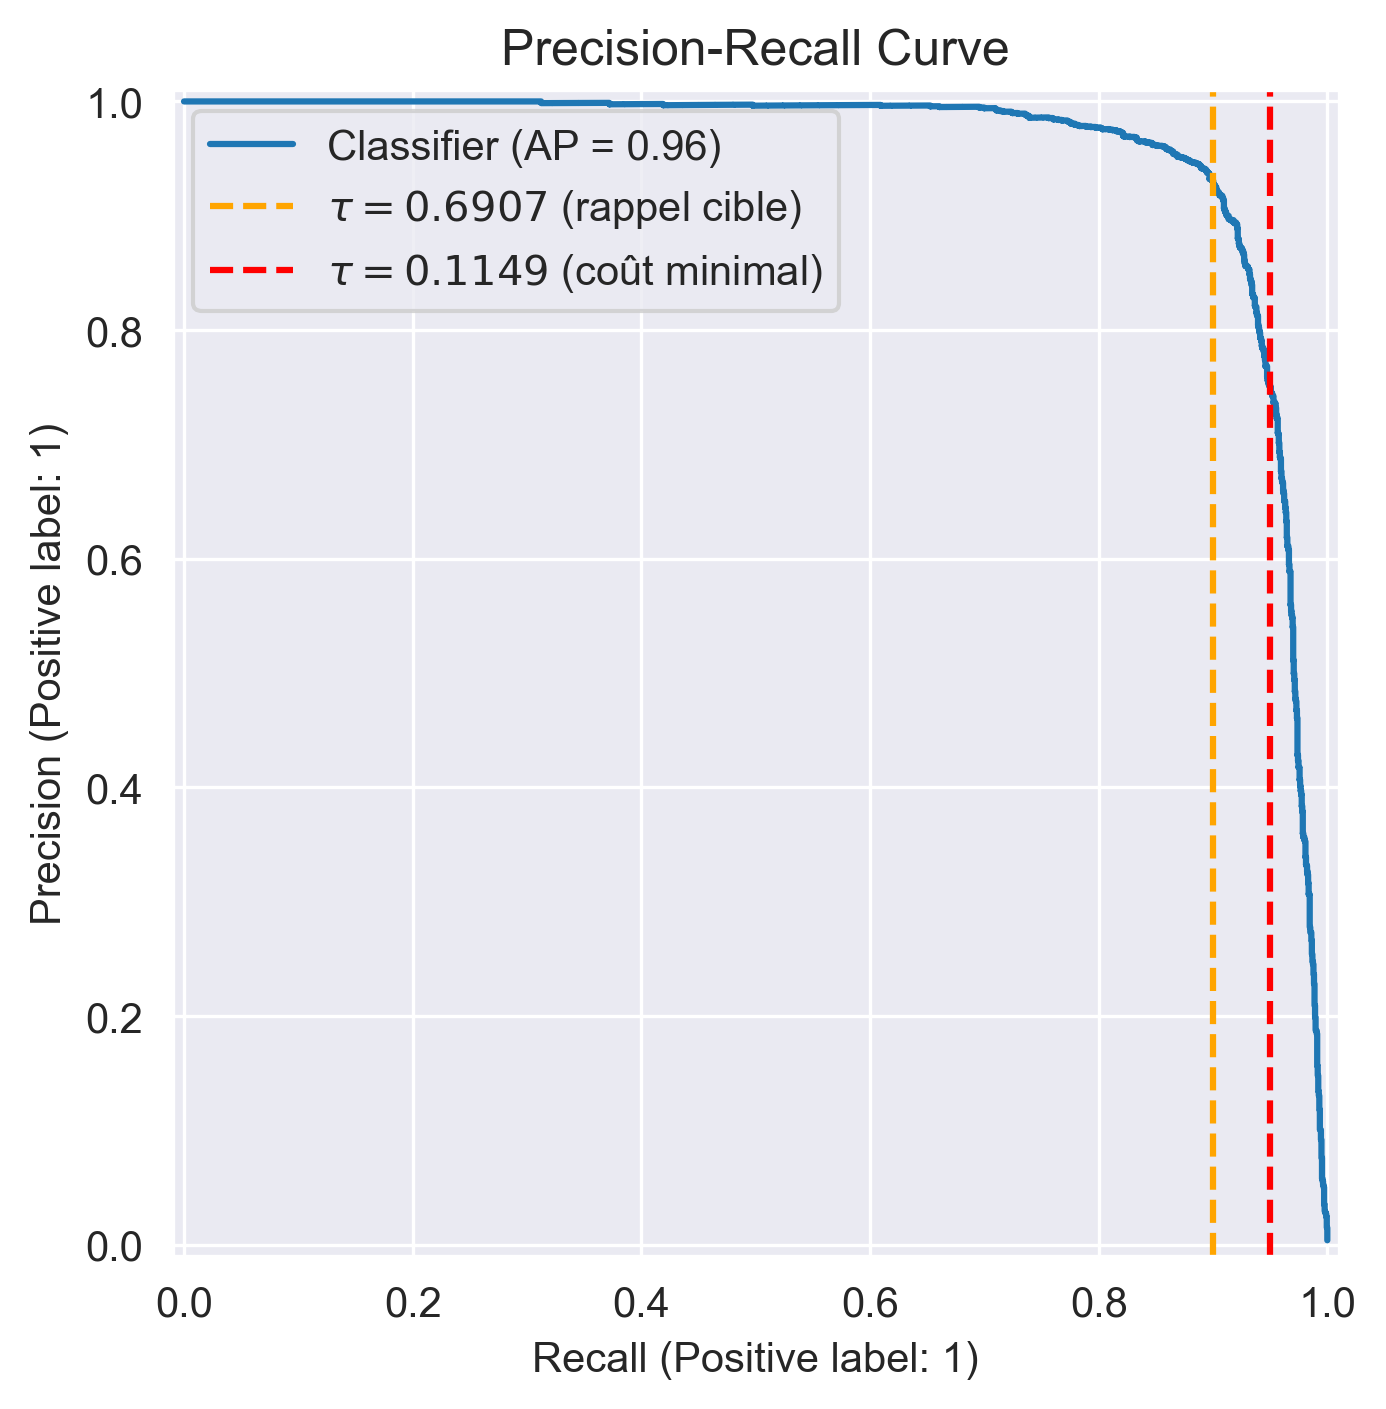

In [146]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
# Assuming y_test contains your true labels
# and y_pred_custom contains your thresholded predictions

# 1. Print the text-based classification report (Precision, Recall, F1-score)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom))

# 2. Print raw numerical confusion matrix
print("--- Raw Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_custom,normalize="true")
print(cm)

fig, ax = plt.subplots( dpi=300)
disp = PrecisionRecallDisplay.from_predictions(y_test, y_proba,ax=ax)
disp.ax_.set_title("Precision-Recall Curve")
plt.axvline(x=0.90, color='orange', linestyle='--', label=r'$\tau=0.6907$ (rappel cible)')
plt.axvline(x=0.95, color='red',    linestyle='--', label=r'$\tau=0.1149$ (coût minimal)')
plt.legend()
plt.tight_layout()
plt.show()

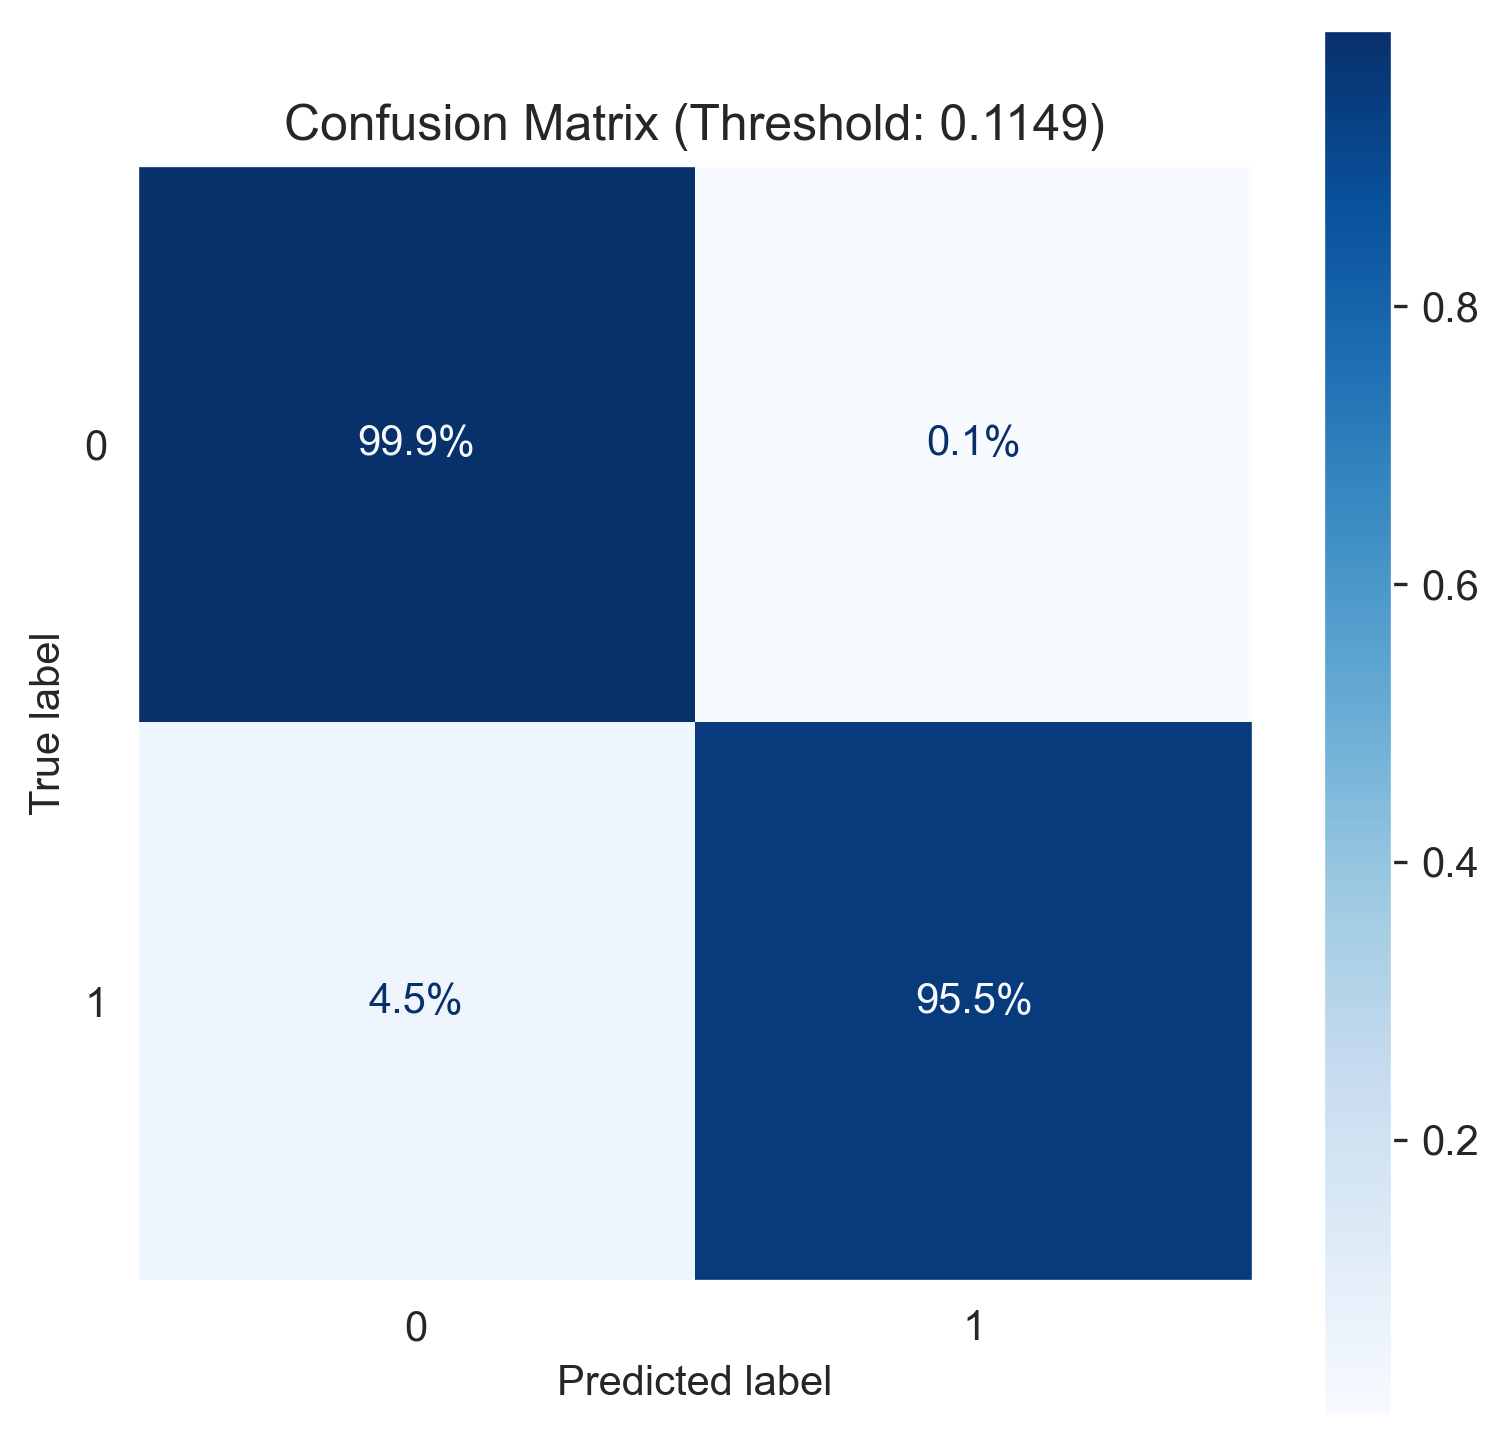

In [147]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay



fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp = ConfusionMatrixDisplay.from_predictions(y_test,y_pred_custom,normalize='true',values_format=".1%", display_labels=final_model.classes_,cmap='Blues',ax=ax)

ax.grid(False)


plt.title(f"Confusion Matrix (Threshold: {best_threshold})")
plt.show()

In [150]:
final_model.save_model('./xgb_fraud_model.json')

In [151]:
print(final_model.get_booster().feature_names)

['amt', 'time_of_day', 'day_of_week', 'day_of_month', 'month', 'age', 'tx_count_1h', 'tx_count_24h', 'amt_sum_24h', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']
